# L1.10 — Recovery

**Level 1 · Core · 45 minutes**

**Goal.** You can decide when an aircraft can go back to its plan.

**Check at the end.** You can say which criterion gives more separation, and which gives a shorter
flight.

> Level 1 uses no simulation loop. This lesson builds a small one by hand, from the modules you
> already know. Lesson L2.1 gives you the real one.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. The contract

```python
class RecoveryCriterion:
    def should_resume(own, intr, rpz) -> bool: ...
```

One pair, one instant, one answer. `True` means "the danger has passed, go back to the plan".

Without a recovery criterion an aircraft that starts to avoid **never stops**. It holds the
avoidance velocity for the rest of the run and never reaches its waypoint. So a resolver without a
recovery rule is not a complete stack.

Three criteria ship, and they ask three different questions.

| Criterion | The question it asks |
| --- | --- |
| `PastCPA` | Are we moving apart, and are we outside the zone now? |
| `FTR` | If I go back to my plan **now**, do we stay clear? |
| `ProbabilisticFTR` | The same question, but with the uncertainty of both velocities in it. |

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN, PURPLE = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c", "#9467bd"

from opencdarr import (
    FTR,
    M600,
    MVP,
    MotionCommand,
    PastCPA,
    ProbabilisticFTR,
    StateBased,
    create_aircraft,
    create_conflict,
    geo,
)
from opencdarr.cd.base import is_los
from opencdarr.kinematics import Multirotor
from opencdarr.relative import relative_enu, segment_min_range, velocity_enu
from opencdarr.state import DesiredVelocity

RPZ, DT = 50.0, 1.0
MR, DETECT, RESOLVE = Multirotor(), StateBased(), MVP(margin=1.05)

# both aircraft carry the velocity they would rather be flying — FTR reads it
own0 = dataclasses.replace(
    create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0,
                    pos_ci95=10.0, vel_ci95=1.0),
    desired=DesiredVelocity.from_track_speed(0.0, 10.0))
intr0 = create_conflict(own0, intr_id="INT", dpsi=90.0, dcpa=0.0, tlos=60.0, rpz=RPZ, gs_intr=10.0)
intr0 = dataclasses.replace(intr0, desired=DesiredVelocity.from_track_speed(intr0.trk, intr0.gs))

print(f"own desired    trk {own0.desired.trk:5.1f} deg at {own0.desired.gs:.1f} m/s")
print(f"intr desired   trk {intr0.desired.trk:5.1f} deg at {intr0.desired.gs:.1f} m/s")

own desired    trk   0.0 deg at 10.0 m/s
intr desired   trk  90.0 deg at 10.0 m/s


## 2. What each one computes

**`PastCPA`** is two tests on the current geometry:

```
past_cpa = r . v > 0        # the range is growing
resume   = past_cpa and not is_los(own, intr, rpz)
```

`bouncing_guard=True` adds a third test that refuses to resume on a near-parallel conflict still
close to the zone. Without it, an aircraft can resume, immediately re-detect, and start to avoid
again — the oscillation the guard exists to stop.

**`FTR`** (Follow-The-Rules) does not look at the current velocity at all. It asks a question about
a **future** it has not flown yet: if the ownship reverts to `desired` and the intruder holds what
it is observed to be doing, does the pair stay outside `rpz`? It needs `own.desired`, and it raises
if that is missing.

**`ProbabilisticFTR`** asks the same question, and integrates over the velocity uncertainty of both
aircraft. It resumes only when the probability of staying clear is above `prob_threshold`.

In [2]:
criteria = {
    "PastCPA": PastCPA(),
    "PastCPA + guard": PastCPA(bouncing_guard=True),
    "FTR": FTR(),
    "ProbabilisticFTR": ProbabilisticFTR(prob_threshold=0.999),
}

for name, rule in criteria.items():
    print(f"{name:<20} at the start of the encounter: resume = "
          f"{rule.should_resume(own0, intr0, RPZ)}")

PastCPA              at the start of the encounter: resume = False
PastCPA + guard      at the start of the encounter: resume = False
FTR                  at the start of the encounter: resume = False
ProbabilisticFTR     at the start of the encounter: resume = False


## 3. Build the smallest loop that uses all four modules

Detection, resolution, recovery and kinematics, in the order of the step. This is the shape of
`run_fleet`, with one aircraft avoiding and the other holding its course.

The rule to see in the code: once an aircraft is **resolving**, it stays resolving until the
recovery criterion says otherwise. Detection alone does not turn the avoidance off.

In [3]:
def encounter(recovery, n: int = 140):
    """Fly the pair. The ownship avoids with MVP and resumes when `recovery` allows it.

    Returns the two tracks, the resolving flag per step, and the true minimum separation.
    """
    own, intr = own0, intr0
    resolving = False
    own_track, intr_track, flags, closest = [own], [intr], [], []

    for _ in range(n):
        if resolving:
            resolving = not (recovery is not None
                             and recovery.should_resume(own, intr, RPZ))
        else:
            resolving = DETECT.detect(own, intr, RPZ, t_lookahead=120.0)

        command = (RESOLVE.resolve(own, [intr], RPZ) if resolving
                   else MotionCommand(target_velocity=(own.desired.v_east, own.desired.v_north)))

        before = relative_enu(own, intr)
        own = MR.step(own, command, M600, DT)
        intr = MR.step(intr, MotionCommand(target_velocity=(intr.desired.v_east,
                                                            intr.desired.v_north)), M600, DT)
        own = dataclasses.replace(own, desired=own0.desired)      # the plan does not change
        intr = dataclasses.replace(intr, desired=intr0.desired)

        closest.append(segment_min_range(before, relative_enu(own, intr)))
        flags.append(resolving)
        own_track.append(own)
        intr_track.append(intr)

    return own_track, intr_track, np.array(flags), min(closest)


runs = {name: encounter(rule) for name, rule in criteria.items()}
runs["no recovery"] = encounter(None)

print(f"{'recovery':<20}{'resumes at':>12}{'seconds avoiding':>19}{'min sep':>11}"
      f"{'distance flown':>17}")
for name, (own_track, _, flags, min_sep) in runs.items():
    idx = np.flatnonzero(~flags & (np.arange(len(flags)) > np.argmax(flags)))
    resume_at = f"{idx[0] * DT:.0f} s" if len(idx) else "never"
    print(f"{name:<20}{resume_at:>12}{flags.sum() * DT:>17.0f} s{min_sep:>9.1f} m"
          f"{own_track[-1].distance_flown:>15.0f} m")

recovery              resumes at   seconds avoiding    min sep   distance flown
PastCPA                     64 s               64 s     52.5 m           1364 m
PastCPA + guard             64 s               64 s     52.5 m           1364 m
FTR                         61 s               61 s     50.5 m           1365 m
ProbabilisticFTR           135 s              135 s     52.5 m           1737 m
no recovery                never              140 s     52.5 m           1775 m


## 4. When each one lets go

Ask every criterion at every step of one flown encounter, and plot the answers together with the
separation. The criteria are pure functions of the pair, so you can ask all four about the same
trajectory.

One result to read carefully. On **this** trajectory `ProbabilisticFTR` never clears its threshold,
even when the pair is a kilometre apart and moving away. That is not the same as the row in section
3, where it resumed at 135 s on a trajectory it flew itself.

The reason is what it integrates. It works from the closest approach of the **infinite** line
through the current relative position along the relative velocity. Once a pair has already passed
close, that line still runs near the ownship — the near miss is behind them, but the line does not
know that. So the probability of clearing `rpz` stays low, and the criterion stays conservative.

This is deliberate, not an oversight. `_p_offset_gt` in the source calls it the "sign-of-`t_cpa`
agnostic" offset: the reference formulation is written that way. `PastCPA` takes the other choice,
with an explicit `r . v > 0` test. Know which one your criterion makes before you read its numbers.

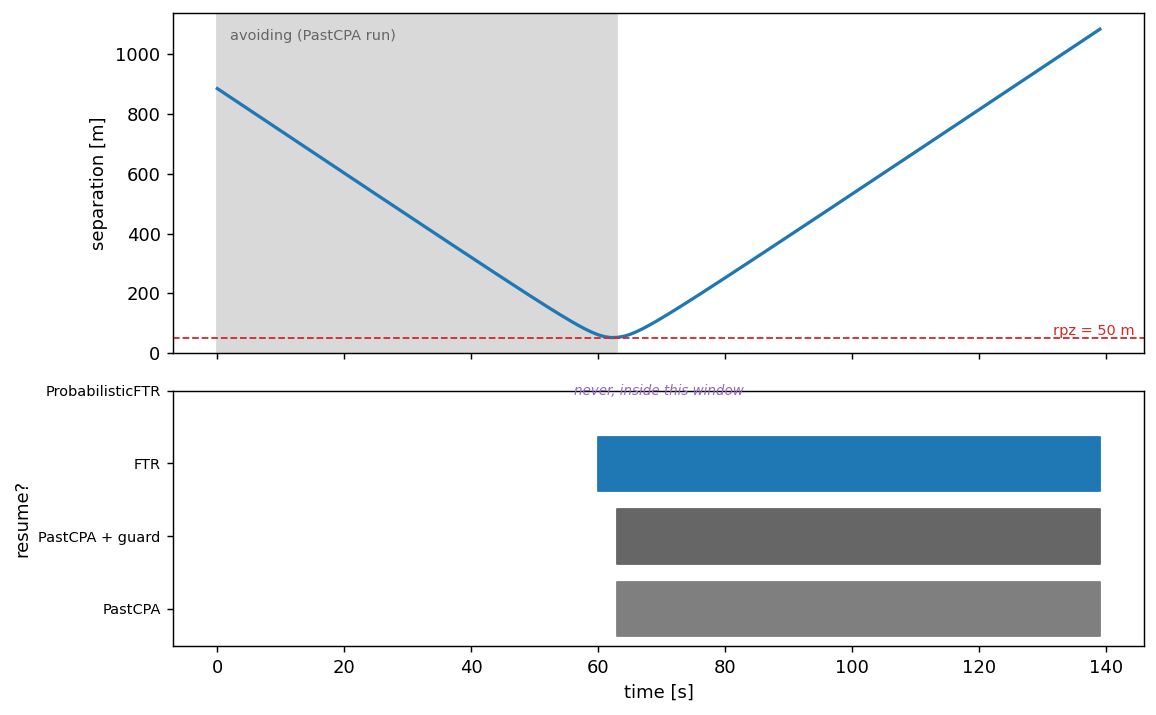

In [4]:
base_own, base_intr, base_flags, _ = runs["PastCPA"]
times = np.arange(len(base_flags)) * DT
gaps = np.array([geo.qdrdist(o.lat, o.lon, i.lat, i.lon)[1]
                 for o, i in zip(base_own[1:], base_intr[1:])])
answers = {name: np.array([rule.should_resume(o, i, RPZ)
                           for o, i in zip(base_own[1:], base_intr[1:])])
           for name, rule in criteria.items()}

fig, (ax_s, ax_r) = plt.subplots(2, 1, figsize=(9.0, 5.6), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 1.5]})

ax_s.plot(times, gaps, lw=1.8, color=BLUE)
ax_s.axhline(RPZ, ls="--", lw=1.0, color=RED)
ax_s.annotate(f"rpz = {RPZ:.0f} m", (0.99, RPZ), xycoords=("axes fraction", "data"), ha="right",
              va="bottom", fontsize=8, color=RED)
ax_s.fill_between(times, 0, gaps.max() * 1.05, where=base_flags, color="0.85", step="mid")
ax_s.annotate("avoiding (PastCPA run)", (times[base_flags][0] + 2, gaps.max()), fontsize=8,
              color="0.4", va="top")
ax_s.set_ylim(0, gaps.max() * 1.05)
ax_s.set_ylabel("separation [m]")

for k, (name, flags) in enumerate(answers.items()):
    colour = (GREY, "0.4", BLUE, PURPLE)[k]
    ax_r.fill_between(times, k, k + 0.75, where=flags, color=colour, step="mid")
    first = np.flatnonzero(flags)
    if len(first):
        ax_r.annotate(f"{first[0] * DT:.0f} s", (first[0] * DT, k + 0.38), (5, 0),
                      textcoords="offset points", fontsize=7.5, color=colour, va="center")
    else:
        ax_r.annotate("never, inside this window", (times[-1] * 0.5, k + 0.38), fontsize=7.5,
                      color=colour, va="center", ha="center", style="italic")
ax_r.set_yticks(np.arange(len(answers)) + 0.38)
ax_r.set_yticklabels(list(answers), fontsize=8)
ax_r.set_xlabel("time [s]")
ax_r.set_ylabel("resume?")
fig.tight_layout()

## 5. The trade

The closest approach in this encounter happens near t = 63 s, and that one time splits the trade in
two:

- Resume **before** the closest approach and you give separation away. `FTR` resumes at 61 s and
  ends 2 m closer than the others.
- Resume **after** it and the separation is already banked. The extra seconds then cost only
  distance. `ProbabilisticFTR` flies about 370 m further for the same minimum separation.

So "more conservative" does not mean "safer". It means "safer only while the conflict is still in
front of you". Read the two columns of section 3 together, and never quote one without the other.

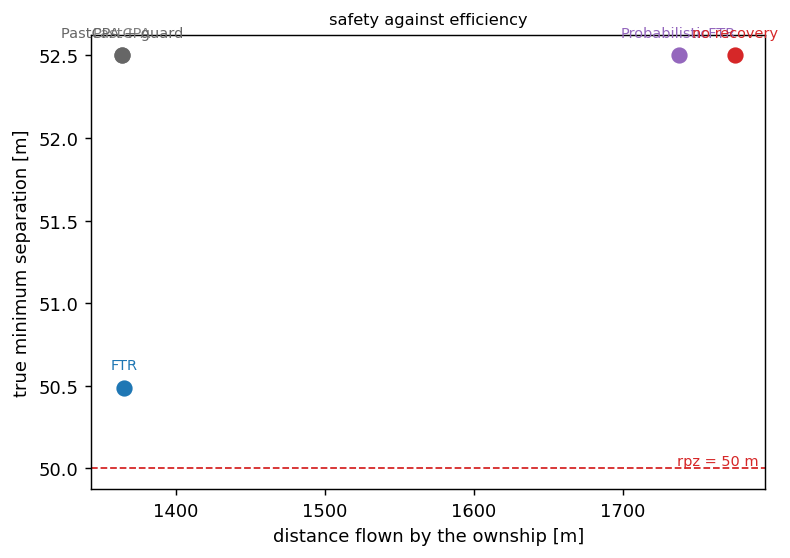

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 4.4))
for (name, (own_track, _, flags, min_sep)), colour in zip(
        runs.items(), (GREY, "0.4", BLUE, PURPLE, RED)):
    ax.plot(own_track[-1].distance_flown, min_sep, marker="o", ms=8, color=colour)
    ax.annotate(name, (own_track[-1].distance_flown, min_sep), (0, 10),
                textcoords="offset points", fontsize=8, color=colour, ha="center")
ax.axhline(RPZ, ls="--", lw=1.0, color=RED)
ax.annotate(f"rpz = {RPZ:.0f} m", (0.99, RPZ), xycoords=("axes fraction", "data"), ha="right",
            va="bottom", fontsize=8, color=RED)
ax.set_xlabel("distance flown by the ownship [m]")
ax.set_ylabel("true minimum separation [m]")
ax.set_title("safety against efficiency", fontsize=9)
fig.tight_layout()

## 6. `FTR` tracks the plan, not the start of the run

`FTR` reads `own.desired` at every call. The loop stamps that field from the **live** nominal of the
autopilot, so an aircraft on a waypoint mission tests reverting to its *current* leg, not to the
velocity it had at `t = 0`.

Change the plan and the answer changes with it. Ask the same criterion about the same geometry with
two different intents.

In [6]:
mid_own = base_own[45]
mid_intr = base_intr[45]

print(f"the same geometry at t = 45 s, separation "
      f"{geo.qdrdist(mid_own.lat, mid_own.lon, mid_intr.lat, mid_intr.lon)[1]:.0f} m\n")
print(f"{'if the plan is':<28}{'FTR resumes':>13}")
for trk in (0.0, 45.0, 90.0, 180.0, 270.0):
    trial = dataclasses.replace(mid_own, desired=DesiredVelocity.from_track_speed(trk, 10.0))
    print(f"{'fly track ' + f'{trk:.0f}' + ' deg':<28}{str(FTR().should_resume(trial, mid_intr, RPZ)):>13}")

print(f"\nPastCPA gives one answer for all of them: "
      f"{PastCPA().should_resume(mid_own, mid_intr, RPZ)}  <- it never reads the plan")

the same geometry at t = 45 s, separation 265 m

if the plan is                FTR resumes
fly track 0 deg                     False
fly track 45 deg                     True
fly track 90 deg                     True
fly track 180 deg                    True
fly track 270 deg                    True

PastCPA gives one answer for all of them: False  <- it never reads the plan


## Do it yourself

1. Set `prob_threshold=0.9` on `ProbabilisticFTR`. Compare the resume time with 0.999.
2. Increase `pos_ci95` and `vel_ci95` on both aircraft to 40 m and 4 m/s. Run section 3 again.
   `ProbabilisticFTR` is the only criterion that reads them.
3. Make the pair near-parallel (`dpsi=5`). Compare `PastCPA()` with `PastCPA(bouncing_guard=True)`.
4. Remove `desired` from `own0` and call `FTR`. Read the error.

## Check

1. Which criterion gives more separation? Which gives a shorter flight?
2. What happens to an aircraft that has a resolver and no recovery criterion?
3. `FTR` reads `own.desired`. Why does that make it track a mission instead of a fixed velocity?

## Next

`L1.11 — Wind`. The CDaRR stack is complete. Next you put it in an environment that moves.